# UTS Data Science — Prediksi Gaji Menggunakan Regresi Linear

Nama: Alini Syawalia Riski Fenanda
NIM: 240401010213
Prodi: Informatika
Mata Kuliah: Data Science  

Notebook ini membangun pipeline machine learning end-to-end untuk memprediksi gaji berdasarkan pengalaman kerja, pendidikan, dan kota kerja. Tahapan yang dilakukan meliputi pembuatan dataset sintetis, eksplorasi data, preprocessing, pelatihan model regresi linear, evaluasi model, visualisasi hasil, serta interpretasi.

## 1. Import Library

Pada tahap ini, kita mengimpor library yang dibutuhkan untuk manipulasi data, visualisasi, preprocessing, modeling, dan evaluasi model.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 2. Generate Dataset Sintetis

Dataset sintetis dibuat untuk merepresentasikan kasus prediksi gaji di dunia nyata. Variabel yang digunakan adalah pengalaman kerja, tingkat pendidikan, kota tempat bekerja, dan gaji sebagai target prediksi.

In [2]:
np.random.seed(42)

n = 300

pengalaman = np.random.uniform(0, 20, n)

edu = np.random.choice([0, 1, 2], n)

kota = np.random.choice(
    ["Jakarta", "Surabaya", "Bandung"],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == "Jakarta", 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    "pengalaman": pengalaman,
    "edu": edu,
    "kota": kota,
    "gaji": gaji
})

df.head()

,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


## 3. Eksplorasi Data Awal

Eksplorasi data dilakukan untuk memahami struktur dataset, tipe data, statistik deskriptif, serta apakah terdapat missing value.

In [3]:
print("Shape dataset:", df.shape)

display(df.head())

print("\nInformasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe().round(2))

print("\nJumlah Missing Value:")
display(df.isnull().sum())

Shape dataset: (300, 4)


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pengalaman  300 non-null    float64
 1   edu         300 non-null    int64  
 2   kota        300 non-null    object 
 3   gaji        300 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 9.5+ KB

Statistik Deskriptif:


,pengalaman,edu,gaji
count,300.00,300.00,300.00
mean,9.90,0.89,27.40
std,5.89,0.83,13.41
min,0.10,0.00,1.67
25%,4.78,0.00,16.24
50%,10.23,1.00,27.97
75%,15.14,2.00,38.89
max,19.80,2.00,54.22



Jumlah Missing Value:


,0
pengalaman,0
edu,0
kota,0
gaji,0


## 4. Visualisasi Awal

Visualisasi awal digunakan untuk melihat hubungan antara pengalaman kerja dan gaji berdasarkan kota. Secara umum, semakin tinggi pengalaman kerja, gaji cenderung meningkat.

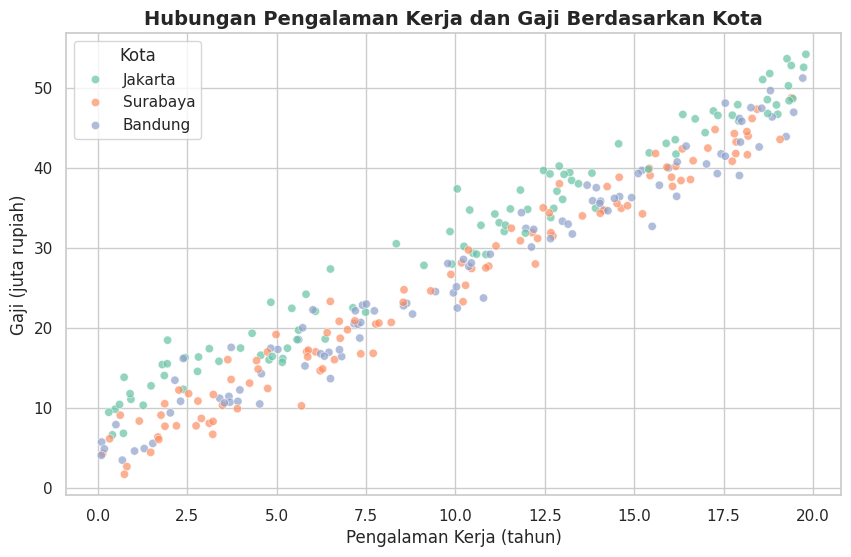

In [4]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="pengalaman",
    y="gaji",
    hue="kota",
    palette="Set2",
    alpha=0.7
)

plt.title("Hubungan Pengalaman Kerja dan Gaji Berdasarkan Kota", fontsize=14, fontweight="bold")
plt.xlabel("Pengalaman Kerja (tahun)")
plt.ylabel("Gaji (juta rupiah)")
plt.legend(title="Kota")
plt.show()

## 5. Analisis Distribusi Data

Distribusi data dianalisis untuk melihat persebaran pengalaman kerja, pendidikan, kota, dan gaji. Tahap ini membantu memahami karakteristik data sebelum dilakukan modeling.

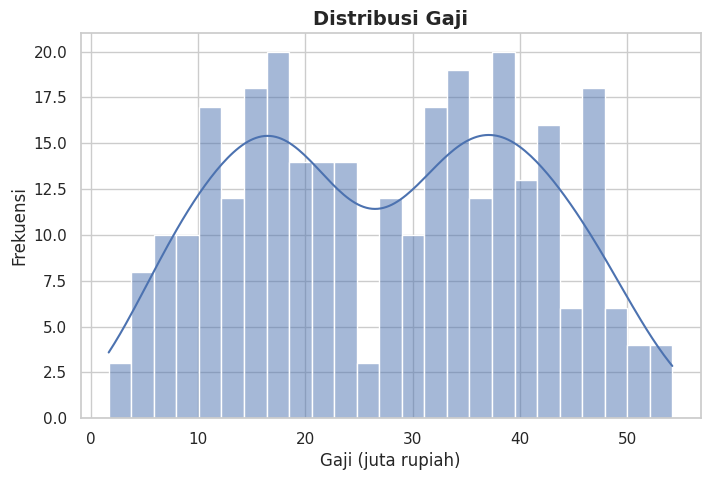

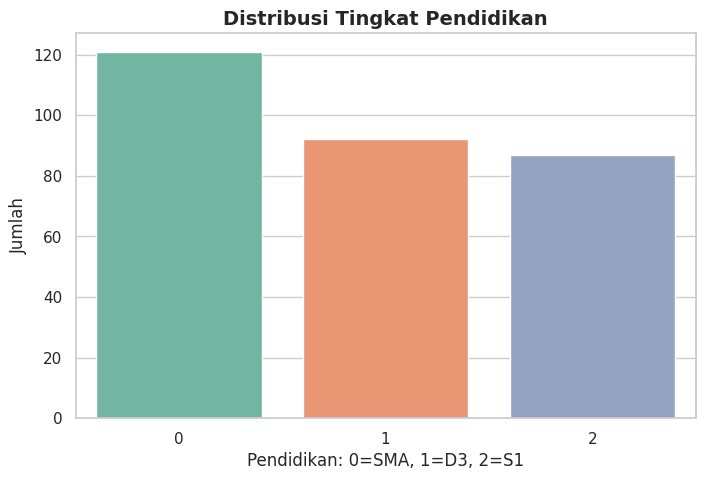

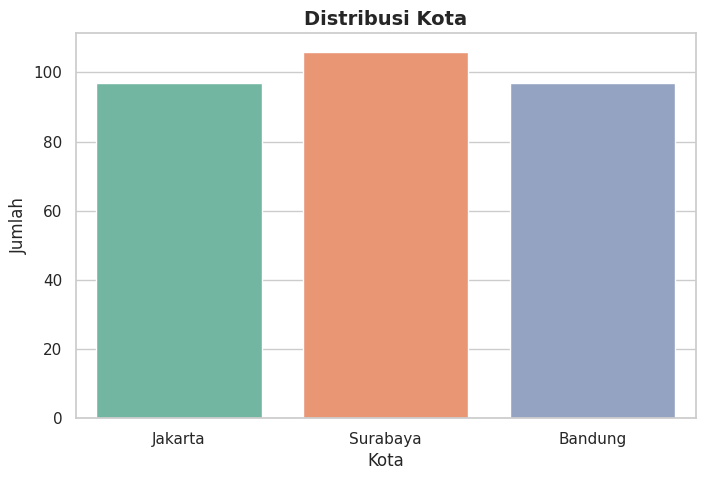

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["gaji"], kde=True, bins=25)
plt.title("Distribusi Gaji", fontsize=14, fontweight="bold")
plt.xlabel("Gaji (juta rupiah)")
plt.ylabel("Frekuensi")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="edu", palette="Set2")
plt.title("Distribusi Tingkat Pendidikan", fontsize=14, fontweight="bold")
plt.xlabel("Pendidikan: 0=SMA, 1=D3, 2=S1")
plt.ylabel("Jumlah")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="kota", palette="Set2")
plt.title("Distribusi Kota", fontsize=14, fontweight="bold")
plt.xlabel("Kota")
plt.ylabel("Jumlah")
plt.show()

## 6. Preprocessing Data

Pada tahap preprocessing, fitur kategorik kota diubah menjadi numerik menggunakan One-Hot Encoding. Setelah itu, data dibagi menjadi data training dan testing. StandardScaler digunakan agar fitur numerik berada pada skala yang sebanding.

In [6]:
df_encoded = pd.get_dummies(
    df,
    columns=["kota"],
    drop_first=True,
    dtype=int
)

print("Kolom setelah One-Hot Encoding:")
print(df_encoded.columns.tolist())

X = df_encoded.drop("gaji", axis=1)
y = df_encoded["gaji"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Jumlah data training: {X_train.shape[0]} baris")
print(f"Jumlah data testing : {X_test.shape[0]} baris")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Kolom setelah One-Hot Encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Jumlah data training: 240 baris
Jumlah data testing : 60 baris


## 7. Training Model Regresi Linear

Model yang digunakan adalah Regresi Linear. Model ini mempelajari hubungan linear antara fitur input dan target gaji.

In [7]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Model Regresi Linear berhasil dilatih.")

Model Regresi Linear berhasil dilatih.


## 8. Koefisien Model

Koefisien model menunjukkan pengaruh masing-masing fitur terhadap prediksi gaji. Koefisien positif berarti fitur tersebut meningkatkan prediksi gaji, sedangkan koefisien negatif berarti menurunkan prediksi gaji.

In [8]:
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": model.coef_
}).sort_values(by="Koefisien", ascending=False)

print(f"Intercept β₀: {model.intercept_:.3f}")

display(coef_df.round(3))

Intercept β₀: 27.514


,Fitur,Koefisien
0,pengalaman,13.042
2,kota_Jakarta,1.837
1,edu,1.188
3,kota_Surabaya,-0.292


### Interpretasi Koefisien

Berdasarkan koefisien model, fitur dengan nilai koefisien paling besar memiliki pengaruh paling kuat terhadap kenaikan prediksi gaji. Jika fitur pengalaman memiliki koefisien terbesar, maka pengalaman kerja menjadi faktor paling dominan dalam menentukan gaji. Fitur kota juga dapat memengaruhi gaji, terutama jika kota tertentu memiliki standar gaji yang lebih tinggi.

## 9. Evaluasi Model

Evaluasi model dilakukan menggunakan MAE, RMSE, dan R². MAE menunjukkan rata-rata kesalahan prediksi, RMSE memberikan penalti lebih besar pada error besar, sedangkan R² menunjukkan seberapa besar variasi target yang dapat dijelaskan oleh model.

In [9]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("=== Metrik Evaluasi Model ===")
print(f"MAE  : {mae:.3f} juta rupiah")
print(f"RMSE : {rmse:.3f} juta rupiah")
print(f"R²   : {r2:.4f}")
print(f"R² dalam persen: {r2 * 100:.2f}%")
print(f"Selisih RMSE - MAE: {rmse - mae:.3f}")

=== Metrik Evaluasi Model ===
MAE  : 1.649 juta rupiah
RMSE : 2.123 juta rupiah
R²   : 0.9740
R² dalam persen: 97.40%
Selisih RMSE - MAE: 0.474


### Interpretasi Evaluasi

MAE menunjukkan rata-rata kesalahan prediksi model dalam satuan juta rupiah. Semakin kecil MAE, semakin baik model dalam melakukan prediksi.

RMSE biasanya lebih besar daripada MAE karena RMSE memberikan penalti lebih besar pada kesalahan prediksi yang besar. Jika selisih RMSE dan MAE tidak terlalu jauh, maka tidak terdapat indikasi outlier error yang ekstrem.

Nilai R² menunjukkan persentase variasi gaji yang berhasil dijelaskan oleh model. Jika R² mendekati 1, maka model memiliki performa yang sangat baik.

## 10. Visualisasi Evaluasi Model

Visualisasi Actual vs Predicted digunakan untuk melihat kedekatan hasil prediksi dengan nilai aktual. Residual Plot digunakan untuk melihat apakah error tersebar secara acak di sekitar nol.

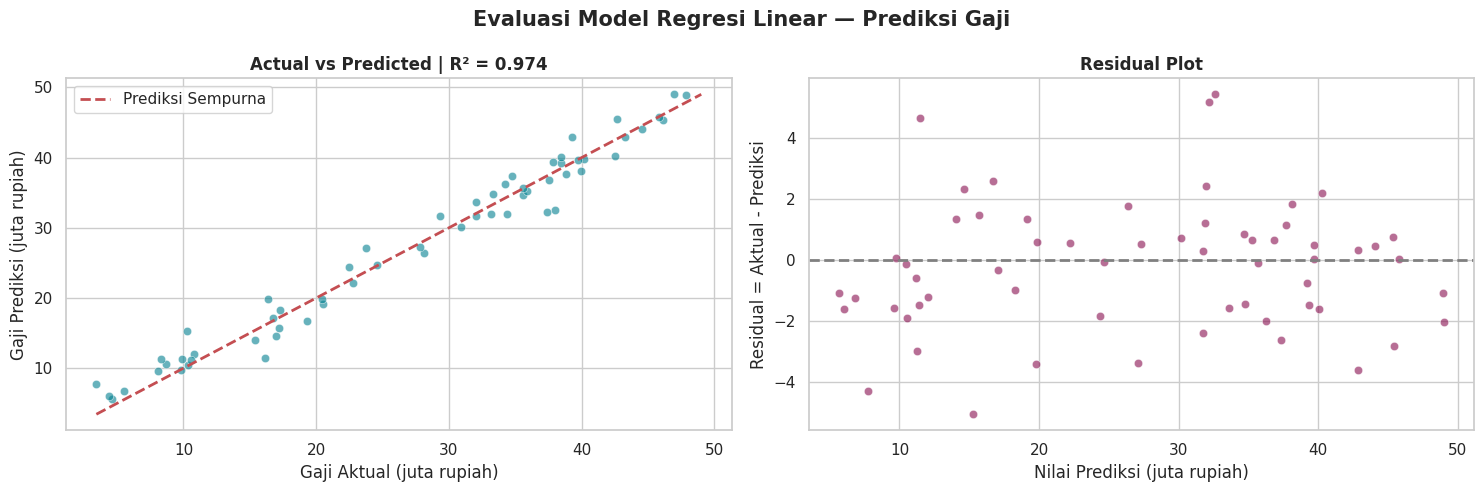

In [10]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6,
    color="#028090",
    edgecolors="white",
    linewidth=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    "r--",
    linewidth=2,
    label="Prediksi Sempurna"
)

axes[0].set_title(f"Actual vs Predicted | R² = {r2:.3f}", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Gaji Aktual (juta rupiah)")
axes[0].set_ylabel("Gaji Prediksi (juta rupiah)")
axes[0].legend()

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.6,
    color="#880E4F",
    edgecolors="white",
    linewidth=0.5
)

axes[1].axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=2
)

axes[1].set_title("Residual Plot", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Nilai Prediksi (juta rupiah)")
axes[1].set_ylabel("Residual = Aktual - Prediksi")

plt.suptitle(
    "Evaluasi Model Regresi Linear — Prediksi Gaji",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("evaluasi_regresi.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Interpretasi Visualisasi

### Plot Actual vs Predicted

**What?**  
Sebagian besar titik berada cukup dekat dengan garis merah putus-putus yang menunjukkan prediksi sempurna.

**So What?**  
Hal ini menunjukkan bahwa model mampu memprediksi gaji dengan cukup baik karena nilai prediksi tidak jauh dari nilai aktual.

**Now What?**  
Model dapat digunakan sebagai baseline untuk prediksi gaji. Namun, performa masih dapat ditingkatkan dengan menambahkan fitur lain seperti bidang pekerjaan, level jabatan, ukuran perusahaan, atau lokasi yang lebih detail.

### Residual Plot

**What?**  
Residual tersebar di sekitar garis nol dan tidak membentuk pola yang terlalu jelas.

**So What?**  
Sebaran residual yang acak menunjukkan bahwa asumsi linearitas cukup terpenuhi. Model tidak menunjukkan bias besar pada rentang prediksi tertentu.

**Now What?**  
Model regresi linear sudah cukup sesuai untuk dataset ini. Jika muncul pola tertentu pada residual, maka model non-linear seperti Decision Tree, Random Forest, atau Gradient Boosting dapat dipertimbangkan.

## 12. Simulasi Prediksi Data Baru

Pada tahap ini, model digunakan untuk memprediksi gaji kandidat baru berdasarkan pengalaman kerja, pendidikan, dan kota.

In [11]:
data_baru = pd.DataFrame({
    "pengalaman": [5],
    "edu": [2],
    "kota": ["Jakarta"]
})

data_baru_encoded = pd.get_dummies(data_baru)

for col in X.columns:
    if col not in data_baru_encoded.columns:
        data_baru_encoded[col] = 0

data_baru_encoded = data_baru_encoded[X.columns]

data_baru_scaled = scaler.transform(data_baru_encoded)

prediksi_gaji = model.predict(data_baru_scaled)

print(f"Prediksi gaji kandidat baru: {prediksi_gaji[0]:.2f} juta rupiah")

Prediksi gaji kandidat baru: 21.07 juta rupiah


## 13. Kesimpulan

Berdasarkan hasil praktikum, model Regresi Linear mampu memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan kota kerja dengan cukup baik. Fitur pengalaman kerja menjadi salah satu faktor yang paling berpengaruh terhadap gaji, karena semakin lama pengalaman kerja seseorang, semakin tinggi gaji yang diprediksi.

Nilai evaluasi seperti MAE, RMSE, dan R² menunjukkan bahwa model memiliki performa yang baik pada dataset sintetis ini. Selain itu, visualisasi Actual vs Predicted dan Residual Plot menunjukkan bahwa hasil prediksi cukup dekat dengan nilai aktual dan residual tersebar relatif acak di sekitar nol.

Untuk pengembangan lebih lanjut, dataset dapat diperluas dengan fitur tambahan seperti jenis pekerjaan, level jabatan, industri, ukuran perusahaan, dan sertifikasi agar model menjadi lebih realistis dan akurat.